In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

### Загрузка и первичный анализ данных

In [2]:
data = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv', sep=",")

In [3]:
# размер набора данных
data.shape

(5268, 14)

In [4]:
# типы колонок
data.dtypes

index             int64
Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object

In [5]:
# проверим есть ли пропущенные значения
data.isnull().sum()

index              0
Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

In [6]:
# Первые 5 строк датасета
data.head()

,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [7]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 5268


## 1) Обработка пропусков в данных

In [8]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Aboard. Тип данных float64. Количество пустых значений 22, 0.42%.
Колонка Fatalities. Тип данных float64. Количество пустых значений 12, 0.23%.
Колонка Ground. Тип данных float64. Количество пустых значений 22, 0.42%.


In [9]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,Aboard,Fatalities,Ground
0,2.0,1.0,0.0
1,5.0,5.0,0.0
2,1.0,1.0,0.0
3,20.0,14.0,0.0
4,30.0,30.0,0.0
...,...,...,...
5263,112.0,98.0,2.0
5264,4.0,4.0,NaN
5265,228.0,228.0,0.0
5266,1.0,1.0,0.0


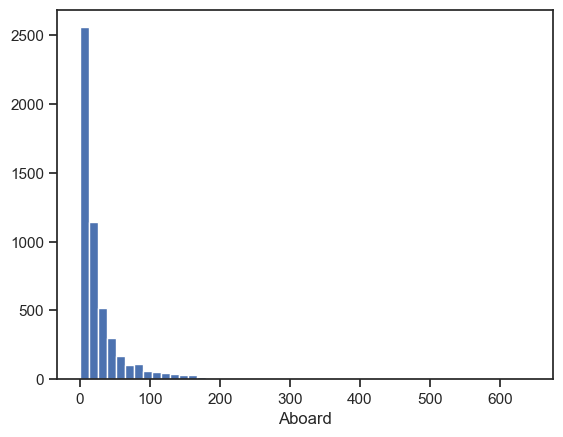

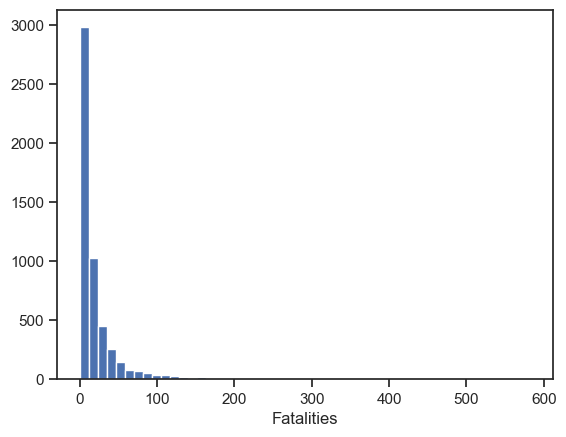

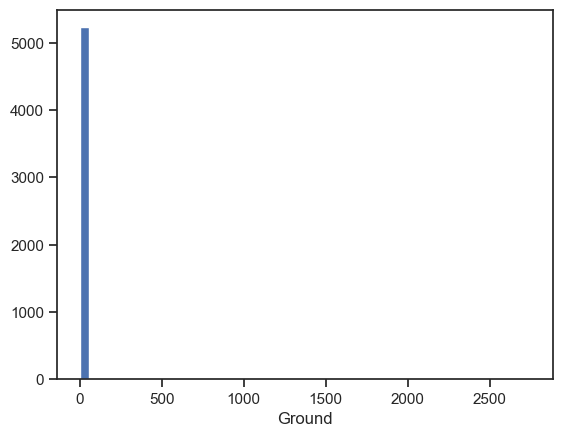

In [10]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [11]:
# Заполнение нулями только численных значений
data_new_3 = data.copy()
numeric_cols = data_new_3.select_dtypes(include=['int64', 'float64']).columns
data_new_3[numeric_cols] = data_new_3[numeric_cols].fillna(0)
data_new_3.head()

,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [12]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Time. Тип данных object. Количество пустых значений 2219, 42.12%.
Колонка Location. Тип данных object. Количество пустых значений 20, 0.38%.
Колонка Operator. Тип данных object. Количество пустых значений 18, 0.34%.
Колонка Flight #. Тип данных object. Количество пустых значений 4199, 79.71%.
Колонка Route. Тип данных object. Количество пустых значений 1707, 32.4%.
Колонка Type. Тип данных object. Количество пустых значений 27, 0.51%.
Колонка Registration. Тип данных object. Количество пустых значений 335, 6.36%.
Колонка cn/In. Тип данных object. Количество пустых значений 1228, 23.31%.
Колонка Summary. Тип данных object. Количество пустых значений 390, 7.4%.


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [14]:
cat_cols = ['Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Summary']
cat_temp_data = data[cat_cols].copy()

In [15]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2_array = imp2.fit_transform(cat_temp_data)
data_imp2_df = pd.DataFrame(data_imp2_array, columns=cat_cols)

In [16]:
print("\nПОСЛЕ импьютации:")
for col in cat_cols:
    print(f"{col}: {data_imp2_df[col].isnull().sum()} пропусков")


ПОСЛЕ импьютации:
Time: 0 пропусков
Location: 0 пропусков
Operator: 0 пропусков
Flight #: 0 пропусков
Route: 0 пропусков
Type: 0 пропусков
Registration: 0 пропусков
cn/In: 0 пропусков
Summary: 0 пропусков


In [17]:
data_cleaned = data_new_3.copy()
cat_cols = ['Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Summary']

data_cleaned = data_cleaned.drop(columns=cat_cols)

data_cleaned = pd.concat([data_cleaned, data_imp2_df], axis=1)

print("\nПервые 5 строк после объединения:")
data_cleaned.head()


Первые 5 строк после объединения:


,index,Date,Aboard,Fatalities,Ground,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Summary
0,0,09/17/1908,2.0,1.0,0.0,17:18,"Fort Myer, Virginia",Military - U.S. Army,-,Demonstration,Wright Flyer III,49,1,"During a demonstration flight, a U.S. Army fly..."
1,1,07/12/1912,5.0,5.0,0.0,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,-,Test flight,Dirigible,49,178,First U.S. dirigible Akron exploded just offsh...
2,2,08/06/1913,1.0,1.0,0.0,15:00,"Victoria, British Columbia, Canada",Private,-,Training,Curtiss seaplane,49,178,The first fatal airplane accident in Canada oc...
3,3,09/09/1913,20.0,14.0,0.0,18:30,Over the North Sea,Military - German Navy,-,Training,Zeppelin L-1 (airship),49,178,The airship flew into a thunderstorm and encou...
4,4,10/17/1913,30.0,30.0,0.0,10:30,"Near Johannisthal, Germany",Military - German Navy,-,Training,Zeppelin L-2 (airship),49,178,Hydrogen gas which was being vented was sucked...


## 2) Кодирование категориальных признаков

In [18]:
cat_enc = pd.DataFrame({'c1': data_cleaned['Operator']})
cat_enc.head()

,c1
0,Military - U.S. Army
1,Military - U.S. Navy
2,Private
3,Military - German Navy
4,Military - German Navy


### Использование LabelEncoder

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
cat_enc['c1'].unique()

array(['Military - U.S. Army', 'Military - U.S. Navy', 'Private', ...,
       'Aerotuy airline', 'Bako Air', 'Strait Air'],
      shape=(2476,), dtype=object)

In [21]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

In [22]:
# Наименования категорий в соответствии с порядковыми номерами

# Свойство называется classes, потому что предполагается что мы решаем 
# задачу классификации и каждое значение категории соответствует 
# какому-либо классу целевого признака

le.classes_

array(['A B Aerotransport', 'AB Aerotransport', 'ACES Colombia', ...,
       'Zantop International Airlines', 'Zen Nippon',
       'de Havilland Aircraft'], shape=(2476,), dtype=object)

In [23]:
cat_enc_le

array([1566, 1577, 1823, ...,  197, 2122, 1474], shape=(5268,))

In [24]:
np.unique(cat_enc_le)

array([   0,    1,    2, ..., 2473, 2474, 2475], shape=(2476,))

In [25]:
le.inverse_transform([0, 1, 2, 3])

array(['A B Aerotransport', 'AB Aerotransport', 'ACES Colombia',
       'ADC Airlines'], dtype=object)

### Кодирование категорий наборами бинарных значений - one-hot encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['c1']])

In [28]:
cat_enc.shape

(5268, 1)

In [29]:
cat_enc_ohe.shape

(5268, 2476)

In [30]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5268 stored elements and shape (5268, 2476)>

In [31]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(10, 2476))

In [32]:
cat_enc.head(10)

,c1
0,Military - U.S. Army
1,Military - U.S. Navy
2,Private
3,Military - German Navy
4,Military - German Navy
5,Military - German Navy
6,Military - German Navy
7,Military - German Army
8,Military - German Navy
9,Military - German Navy


## 3) Масштабирование данных

In [33]:
# Числовые признаки для масштабирования
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
print("Числовые столбцы:", numeric_cols)

Числовые столбцы: ['index', 'Aboard', 'Fatalities', 'Ground']


In [34]:
numeric_features = ['Aboard', 'Fatalities', 'Ground']

### MinMax масштабирование

In [36]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

In [37]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data_cleaned[['Aboard']])

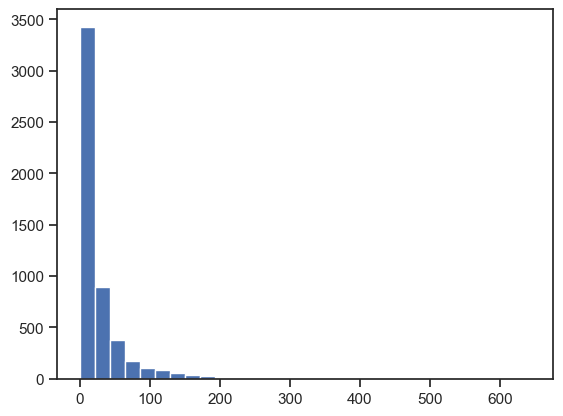

In [38]:
plt.hist(data['Aboard'], 30)
plt.show()

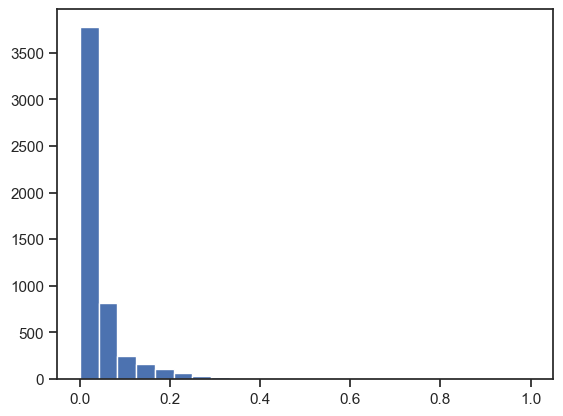

In [39]:
plt.hist(sc1_data, 24)
plt.show()

### Масштабирование данных на основе Z-оценки - StandardScaler

In [40]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Aboard']])

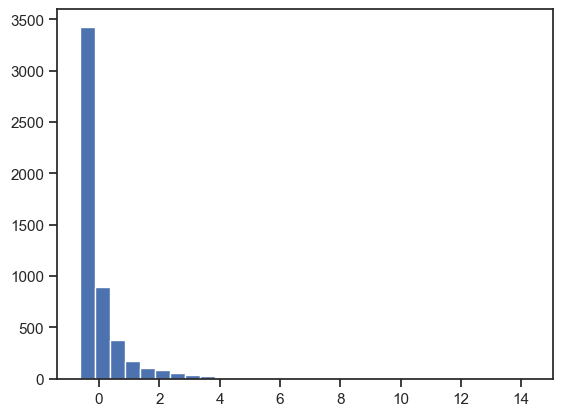

In [41]:
plt.hist(sc2_data, 30)
plt.show()